In [38]:
!pip install watermark

In [40]:
!pip install torchinfo

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
from torch.utils.tensorboard import SummaryWriter
from torchinfo import summary
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix
from transformers import AutoTokenizer, AutoModel
from tqdm import tqdm
import gzip
import pickle
import os

In [36]:
import warnings
warnings.filterwarnings("ignore")

In [39]:
# Print versions using watermark
%reload_ext watermark
%watermark -v -m -p numpy,pandas,matplotlib,seaborn,torch,sklearn,transformers

Python implementation: CPython
Python version       : 3.10.12
IPython version      : 7.34.0

numpy       : 1.26.4
pandas      : 2.2.3
matplotlib  : 3.7.5
seaborn     : 0.12.2
torch       : 2.5.1+cu121
sklearn     : 1.2.2
transformers: 4.47.0

Compiler    : GCC 11.4.0
OS          : Linux
Release     : 6.6.56+
Machine     : x86_64
Processor   : x86_64
CPU cores   : 4
Architecture: 64bit



In [19]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device

device(type='cuda')

## Dataset Preparation

In [5]:
!wget -O train.tsv "https://raw.githubusercontent.com/clairett/pytorch-sentiment-classification/master/data/SST2/train.tsv"
!wget -O test.tsv "https://raw.githubusercontent.com/clairett/pytorch-sentiment-classification/master/data/SST2/test.tsv"

--2025-03-15 11:50:26--  https://raw.githubusercontent.com/clairett/pytorch-sentiment-classification/master/data/SST2/train.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.110.133, 185.199.109.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.110.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 720259 (703K) [text/plain]
Saving to: ‘train.tsv’

train.tsv           100%[===================>] 703.38K  --.-KB/s    in 0.05s   

2025-03-15 11:50:26 (14.6 MB/s) - ‘train.tsv’ saved [720259/720259]

--2025-03-15 11:50:26--  https://raw.githubusercontent.com/clairett/pytorch-sentiment-classification/master/data/SST2/test.tsv
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.109.133, 185.199.110.133, 185.199.108.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.109.133|:443... connected.
HTTP request sent, awaiting response...

In [41]:
# Load the dataset
train_df = pd.read_csv("train.tsv", delimiter="\t", header=None, names=["Review","Sentiment"])
test_df = pd.read_csv("test.tsv", delimiter="\t", header=None, names=["Review","Sentiment"])

In [42]:
# Load IMDB dataset
imdb_df = pd.read_csv("https://raw.githubusercontent.com/Ankit152/IMDB-sentiment-analysis/master/IMDB-Dataset.csv")
imdb_df["sentiment"] = imdb_df["sentiment"].map({"positive": 1, "negative": 0})

In [43]:
train_df.sample(5)

,Review,Sentiment
6887,it 's supposed to be post feminist breezy but ...,0
6771,execrable,0
5925,"forget the misleading title , what 's with the...",0
687,a must see for fans of thoughtful war films an...,1
3424,this is an undeniably intriguing film from an ...,1


In [44]:
X_train = train_df['Review']
y_train = train_df['Sentiment']
X_test = test_df['Review']
y_test = test_df['Sentiment']

In [45]:
# Split training data into train and validation (80-20 split)
X_train, X_val, y_train, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42)

In [46]:
print(f"Shape of training data: {X_train.shape}")
print(f"Shape of validation data: {X_val.shape}")
print(f"Shape of testing data: {X_test.shape}")

Shape of training data: (5536,)
Shape of validation data: (1384,)
Shape of testing data: (1821,)


## Construct a Multi-Layer Perceptron (MLP) model.

In [47]:
class MLPModel(nn.Module):
    def __init__(self, input_size=10000, hidden_sizes=[512, 256, 128, 64], output_size=2):
        super(MLPModel, self).__init__()

        # Define layers
        self.fc1 = nn.Linear(input_size, hidden_sizes[0])
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.fc3 = nn.Linear(hidden_sizes[1], hidden_sizes[2])
        self.fc4 = nn.Linear(hidden_sizes[2], hidden_sizes[3])
        self.fc5 = nn.Linear(hidden_sizes[3], output_size)
        self.relu = nn.ReLU()
        self.dropout = nn.Dropout(0.3)  # Dropout for regularization

    def forward(self, x):
        x = self.dropout(self.relu(self.fc1(x)))
        x = self.dropout(self.relu(self.fc2(x)))
        x = self.dropout(self.relu(self.fc3(x)))
        x = self.dropout(self.relu(self.fc4(x)))
        x = self.fc5(x)
        return x


In [48]:
# Initialize Model
model = MLPModel()

# Print Summary (batch_size=1, input_size=10000)
summary(model, input_size=(1, 10000), col_names=["input_size", "output_size", "num_params", "trainable"])

Layer (type:depth-idx)                   Input Shape               Output Shape              Param #                   Trainable
MLPModel                                 [1, 10000]                [1, 2]                    --                        True
├─Linear: 1-1                            [1, 10000]                [1, 512]                  5,120,512                 True
├─ReLU: 1-2                              [1, 512]                  [1, 512]                  --                        --
├─Dropout: 1-3                           [1, 512]                  [1, 512]                  --                        --
├─Linear: 1-4                            [1, 512]                  [1, 256]                  131,328                   True
├─ReLU: 1-5                              [1, 256]                  [1, 256]                  --                        --
├─Dropout: 1-6                           [1, 256]                  [1, 256]                  --                        --
├─Linear: 1

## Implement case 1: Bag-of-words

In [49]:
vectorizer = CountVectorizer(max_features=10000)
X_train_bow = vectorizer.fit_transform(X_train).toarray()
X_val_bow = vectorizer.transform(X_val).toarray()
X_test_bow = vectorizer.transform(X_test).toarray()

##  Implement case 2: Construct a function to use LLaMa-3.1 embeddings on the same model.

In [ ]:
from huggingface_hub import login
from kaggle_secrets import UserSecretsClient
user_secrets = UserSecretsClient()
hf_token = user_secrets.get_secret("hf_token")

login(token=hf_token)

In [ ]:
class LLaMaEmbedding:
    def __init__(self, model_name="meta-llama/Llama-3.1-8B"):
        self.device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
        print(f"Using device: {self.device}")

        # Load tokenizer
        self.tokenizer = AutoTokenizer.from_pretrained(model_name)
        self.tokenizer.pad_token = self.tokenizer.eos_token  # Set padding token

        # Load model with FP16 for memory efficiency
        self.model = AutoModel.from_pretrained(model_name, torch_dtype=torch.float16).to(self.device)

        # Store embedding size
        self.embedding_size = self.model.config.hidden_size

    def get_embedding(self, text):
        inputs = self.tokenizer(text, return_tensors="pt", padding=True, truncation=True, max_length=512).to(self.device)
        
        with torch.no_grad():
            outputs = self.model(**inputs)

        return outputs.last_hidden_state.mean(dim=1).squeeze(0).cpu().numpy() # Convert to NumPy

def process_in_batches(texts, embedder, batch_size=16):
    """Processes text data in batches to avoid memory overload."""
    embeddings = []

    for i in tqdm(range(0, len(texts), batch_size), desc="Generating embeddings"):
        batch_texts = texts[i : i + batch_size]
        batch_embeddings = [embedder.get_embedding(text) for text in batch_texts]
        embeddings.extend(batch_embeddings)  # Store results

        torch.cuda.empty_cache()  # Free GPU memory

    return np.array(embeddings)  # Convert list to NumPy array

In [ ]:
# Initialize LLaMa embedder
llama_embedder = LLaMaEmbedding()

In [ ]:
# Compute embeddings
X_train_llama = process_in_batches(X_train, llama_embedder)
X_val_llama = process_in_batches(X_val, llama_embedder)
X_test_llama = process_in_batches(X_test, llama_embedder)

In [ ]:
save_path = "/kaggle/working/"

# Save embeddings
np.save(save_path + "X_train_llama.npy", X_train_llama)
np.save(save_path + "X_val_llama.npy", X_val_llama)
np.save(save_path + "X_test_llama.npy", X_test_llama)

print(f"Embeddings saved in {save_path}")

In [50]:
# Loading previously saved embeddings
X_train_llama = np.load("/kaggle/input/X_train_llama.npy")
X_val_llama = np.load("/kaggle/input/X_val_llama.npy")
X_test_llama = np.load("/kaggle/input/X_test_llama.npy")

In [51]:
X_train_bow.shape

(5536, 10000)

In [52]:
X_train_llama.shape

(5536, 4096)

In [53]:
# Convert labels to NumPy arrays before converting to PyTorch tensors
y_train = torch.tensor(y_train.to_numpy(), dtype=torch.long)
y_val = torch.tensor(y_val.to_numpy(), dtype=torch.long)
y_test = torch.tensor(y_test.to_numpy(), dtype=torch.long)

In [54]:
# Hyperparameters
HYPERPARAMS = {
    "input_size": 10000, 
    "hidden_sizes": [512, 256, 128, 64],  
    "output_size": 2,  
    "epochs": 10,
    "batch_size": 32,
    "learning_rate": 0.0001
}

In [55]:
import os

def save_compressed_checkpoint(checkpoint, checkpoint_path):
    
    compressed_checkpoint_path = checkpoint_path + ".gz"
    temp_checkpoint_file = checkpoint_path + ".pt"  # Save as .pt file first

    # Save checkpoint as a .pt file first
    with open(temp_checkpoint_file, "wb") as f:
        pickle.dump(checkpoint, f, protocol=pickle.HIGHEST_PROTOCOL)

    # Compress the .pt file into a .gz archive
    with open(temp_checkpoint_file, "rb") as f_in:
        with gzip.open(compressed_checkpoint_path, "wb") as f_out:
            f_out.writelines(f_in)

    
    os.remove(temp_checkpoint_file)

    print(f"Compressed checkpoint saved at: {compressed_checkpoint_path}")


In [56]:
def train_model(model, X_train, y_train, X_val, y_val, checkpoint_path, model_type):
    device = "cuda" if torch.cuda.is_available() else "cpu"
    model.to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=HYPERPARAMS["learning_rate"])
    criterion = torch.nn.CrossEntropyLoss()

    torch.cuda.empty_cache()  # Free up memory

    train_loader = DataLoader(
        TensorDataset(torch.tensor(X_train, dtype=torch.float32), torch.tensor(y_train, dtype=torch.long)),
        batch_size=HYPERPARAMS["batch_size"], shuffle=True, pin_memory=True
    )
    val_loader = DataLoader(
        TensorDataset(torch.tensor(X_val, dtype=torch.float32), torch.tensor(y_val, dtype=torch.long)),
        batch_size=HYPERPARAMS["batch_size"], shuffle=False, pin_memory=True
    )

    # Separate TensorBoard logs for BoW and LLaMa
    writer = SummaryWriter(log_dir=f"runs/{model_type}")  

    best_val_acc = 0.0
    best_model_state = None
    best_optimizer_state = None
    best_loss = None

    for epoch in range(HYPERPARAMS["epochs"]):
        model.train()
        total_train_loss = 0

        for batch_X, batch_y in train_loader:
            batch_X, batch_y = batch_X.to(device), batch_y.to(device)

            optimizer.zero_grad()
            outputs = model(batch_X)
            loss = criterion(outputs, batch_y)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item()

        # Log model parameters (weights & biases)
        for name, param in model.named_parameters():
            writer.add_histogram(f"Parameters/{name}", param.clone().cpu().data.numpy(), epoch)

        # Validation
        model.eval()
        total_val_loss = 0
        val_correct = 0
        val_total = 0
        with torch.no_grad():
            for batch_X, batch_y in val_loader:
                batch_X, batch_y = batch_X.to(device), batch_y.to(device)

                outputs = model(batch_X)
                loss = criterion(outputs, batch_y)
                total_val_loss += loss.item()

                preds = torch.argmax(outputs, axis=1)
                val_correct += (preds == batch_y).sum().item()
                val_total += batch_y.size(0)

        val_acc = val_correct / val_total
        avg_train_loss = total_train_loss / len(train_loader)
        avg_val_loss = total_val_loss / len(val_loader)

        # Log to TensorBoard
        writer.add_scalar("Loss/train", avg_train_loss, epoch)
        writer.add_scalar("Loss/val", avg_val_loss, epoch)
        writer.add_scalar("Accuracy/val", val_acc, epoch)

        print(f"Epoch {epoch+1}: Train Loss = {avg_train_loss:.4f}, Val Loss = {avg_val_loss:.4f}, Val Accuracy = {val_acc:.4f}")

        # Save only the best checkpoint
        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_loss = avg_val_loss
            best_model_state = model.state_dict().copy()
            best_optimizer_state = optimizer.state_dict().copy()

    # Save the final best model in compressed format
    if best_model_state:
        checkpoint = {
            "model_state_dict": best_model_state,
            "optimizer_state_dict": best_optimizer_state,
            "hyperparameters": HYPERPARAMS,
            "performance": {
                "final_loss": best_loss,
                "final_accuracy": best_val_acc
            }
        }
        save_compressed_checkpoint(checkpoint, checkpoint_path)
        print(f"Best model saved with Validation Accuracy: {best_val_acc:.4f}")

    writer.close()
    return model

In [57]:
# Initialize model
model_bow = MLPModel(input_size=10000)

# Train the model
trained_model_bow = train_model(model_bow, X_train_bow, y_train, X_val_bow, y_val, checkpoint_path="mlp_bow", model_type="bow")

Epoch 1: Train Loss = 0.6920, Val Loss = 0.6901, Val Accuracy = 0.5152
Epoch 2: Train Loss = 0.6108, Val Loss = 0.4599, Val Accuracy = 0.7919
Epoch 3: Train Loss = 0.2974, Val Loss = 0.4924, Val Accuracy = 0.7934
Epoch 4: Train Loss = 0.1336, Val Loss = 0.5577, Val Accuracy = 0.8042
Epoch 5: Train Loss = 0.0607, Val Loss = 0.6890, Val Accuracy = 0.7970
Epoch 6: Train Loss = 0.0329, Val Loss = 0.7706, Val Accuracy = 0.8085
Epoch 7: Train Loss = 0.0162, Val Loss = 0.8867, Val Accuracy = 0.8013
Epoch 8: Train Loss = 0.0112, Val Loss = 0.9476, Val Accuracy = 0.8064
Epoch 9: Train Loss = 0.0065, Val Loss = 1.0882, Val Accuracy = 0.7962
Epoch 10: Train Loss = 0.0037, Val Loss = 1.1108, Val Accuracy = 0.8078
Compressed checkpoint saved at: mlp_bow.gz
Best model saved with Validation Accuracy: 0.8085


In [58]:
# Initialize model
model_llama = MLPModel(input_size=X_train_llama.shape[1])

# Train the model
trained_model_llama = train_model(model_llama, X_train_llama, y_train, X_val_llama, y_val, checkpoint_path="mlp_llama", model_type="llama")

Epoch 1: Train Loss = 0.4828, Val Loss = 0.3146, Val Accuracy = 0.8685
Epoch 2: Train Loss = 0.3326, Val Loss = 0.2784, Val Accuracy = 0.8880
Epoch 3: Train Loss = 0.2889, Val Loss = 0.2623, Val Accuracy = 0.8887
Epoch 4: Train Loss = 0.2676, Val Loss = 0.2527, Val Accuracy = 0.8988
Epoch 5: Train Loss = 0.2446, Val Loss = 0.2541, Val Accuracy = 0.8909
Epoch 6: Train Loss = 0.2260, Val Loss = 0.2597, Val Accuracy = 0.8996
Epoch 7: Train Loss = 0.2095, Val Loss = 0.2519, Val Accuracy = 0.9082
Epoch 8: Train Loss = 0.1894, Val Loss = 0.2678, Val Accuracy = 0.9017
Epoch 9: Train Loss = 0.1718, Val Loss = 0.2682, Val Accuracy = 0.8996
Epoch 10: Train Loss = 0.1698, Val Loss = 0.2733, Val Accuracy = 0.9025
Compressed checkpoint saved at: mlp_llama.gz
Best model saved with Validation Accuracy: 0.9082


Confusion Matrix - BoW Model - Test Accuracy: 0.7935


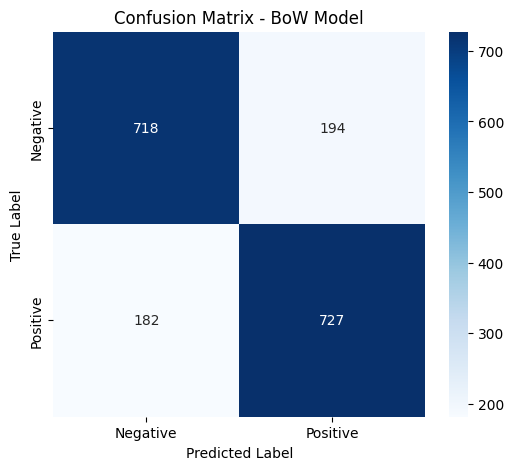

Confusion Matrix - LLaMa Model - Test Accuracy: 0.9116


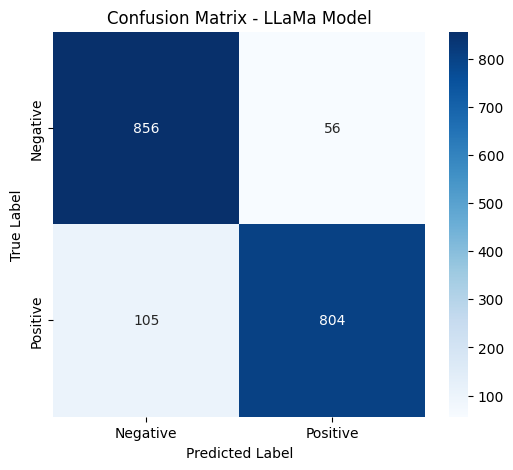

In [59]:
def predict(model, X):
    model.eval()  # Set to evaluation mode
    device = next(model.parameters()).device  # Get model's device
    X_tensor = torch.tensor(X, dtype=torch.float32).to(device)  # Move input data to same device
    
    with torch.no_grad():
        outputs = model(X_tensor)
        predictions = torch.argmax(outputs, axis=1)  # Get predicted class labels
    return predictions.cpu().numpy()  # Move back to CPU for sklearn

def plot_confusion_matrix(model, X, y_true, title="Confusion Matrix"):
    y_pred = predict(model, X)
    
    # Compute confusion matrix and accuracy
    cm = confusion_matrix(y_true, y_pred)
    accuracy = accuracy_score(y_true, y_pred)
    
    # Print accuracy
    print(f"{title} - Test Accuracy: {accuracy:.4f}")
    
    # Plot confusion matrix
    plt.figure(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Negative", "Positive"], yticklabels=["Negative", "Positive"])
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.title(title)
    plt.show()

# Evaluate and plot for both models
plot_confusion_matrix(trained_model_bow, X_test_bow, y_test, title="Confusion Matrix - BoW Model")
plot_confusion_matrix(trained_model_llama, X_test_llama, y_test, title="Confusion Matrix - LLaMa Model")


In [60]:
import pickle

def load_compressed_checkpoint(checkpoint_path, model, device="cpu"):
    with gzip.open(checkpoint_path, "rb") as f:
        checkpoint = pickle.load(f)

    model.load_state_dict(checkpoint["model_state_dict"],strict=False)
    model.to(device)  # Move model to the specified device
    
    print(f"Model loaded from: {checkpoint_path}")
    print(f"Hyperparameters: {checkpoint['hyperparameters']}")
    print(f"Final Accuracy Before Resume: {checkpoint['performance']['final_accuracy']:.4f}\n")

    return model

In [61]:
# Initialize empty model structures
model_bow_z = MLPModel()
model_llama_z = MLPModel(input_size=X_train_llama.shape[1])

# Load saved models from compressed checkpoints
model_bow_z = load_compressed_checkpoint("mlp_bow.gz", model_bow)
model_llama_z = load_compressed_checkpoint("mlp_llama.gz", model_llama)

# Move models to device
device = "cuda" if torch.cuda.is_available() else "cpu"
model_bow_z.to(device)
model_llama_z.to(device)

print("Checkpoint models loaded successfully and ready for further training!")


Model loaded from: mlp_bow.gz
Hyperparameters: {'input_size': 10000, 'hidden_sizes': [512, 256, 128, 64], 'output_size': 2, 'epochs': 10, 'batch_size': 32, 'learning_rate': 0.0001}
Final Accuracy Before Resume: 0.8085

Model loaded from: mlp_llama.gz
Hyperparameters: {'input_size': 10000, 'hidden_sizes': [512, 256, 128, 64], 'output_size': 2, 'epochs': 10, 'batch_size': 32, 'learning_rate': 0.0001}
Final Accuracy Before Resume: 0.9082

Checkpoint models loaded successfully and ready for further training!


## Continual training on IMDB dataset

In [62]:
# Extract IMDB reviews and labels
X_imdb = imdb_df["review"].tolist()
y_imdb = torch.tensor(imdb_df["sentiment"].values, dtype=torch.long)

# Split into training (70%), validation (15%), and test (15%)
X_train_imdb, X_temp_imdb, y_train_imdb, y_temp_imdb = train_test_split(X_imdb, y_imdb, test_size=0.3, random_state=42)
X_val_imdb, X_test_imdb, y_val_imdb, y_test_imdb = train_test_split(X_temp_imdb, y_temp_imdb, test_size=0.5, random_state=42)

In [63]:
# Process BoW features
X_train_imdb_bow = vectorizer.transform(X_train_imdb).toarray()
X_val_imdb_bow = vectorizer.transform(X_val_imdb).toarray()
X_test_imdb_bow = vectorizer.transform(X_test_imdb).toarray()

In [ ]:
# Process LLaMa embeddings
X_train_imdb_llama = process_in_batches(X_train_imdb, llama_embedder)
X_val_imdb_llama = process_in_batches(X_val_imdb, llama_embedder)
X_test_imdb_llama = process_in_batches(X_test_imdb, llama_embedder)

In [ ]:
save_path = "/kaggle/working/"

np.save(save_path + "X_train_imdb_llama.npy", X_train_imdb_llama)
np.save(save_path + "X_val_imdb_llama.npy", X_val_imdb_llama)
np.save(save_path + "X_test_imdb_llama.npy", X_test_imdb_llama)


print("LLaMa embeddings saved successfully!")

In [66]:
X_train_imdb_llama = np.load("/kaggle/input/X_train_imdb_llama.npy")
X_val_imdb_llama = np.load("/kaggle/input/X_val_imdb_llama.npy")
X_test_imdb_llama = np.load("/kaggle/input/X_test_imdb_llama.npy")

print("LLaMa embeddings loaded successfully!")

LLaMa embeddings loaded successfully!


In [67]:
def resume_training(model, X_train, y_train, X_val, y_val, checkpoint_path, model_type):
    print(f"Resuming training with {checkpoint_path} on IMDB dataset...")

    # Resume training with IMDB dataset using train_model()
    return train_model(model, X_train, y_train, X_val, y_val, checkpoint_path=f"{checkpoint_path}_imdb", model_type=model_type)

In [68]:
# Resume training using the already available models
trained_model_bow_imdb = resume_training(model_bow_z, X_train_imdb_bow, y_train_imdb, X_val_imdb_bow, y_val_imdb, checkpoint_path="mlp_bow_2", model_type="bow_2")

Resuming training with mlp_bow_2 on IMDB dataset...
Epoch 1: Train Loss = 0.9615, Val Loss = 0.3155, Val Accuracy = 0.8649
Epoch 2: Train Loss = 0.2645, Val Loss = 0.2828, Val Accuracy = 0.8811
Epoch 3: Train Loss = 0.1856, Val Loss = 0.2958, Val Accuracy = 0.8853
Epoch 4: Train Loss = 0.1074, Val Loss = 0.3337, Val Accuracy = 0.8857
Epoch 5: Train Loss = 0.0550, Val Loss = 0.4353, Val Accuracy = 0.8797
Epoch 6: Train Loss = 0.0379, Val Loss = 0.4474, Val Accuracy = 0.8793
Epoch 7: Train Loss = 0.0285, Val Loss = 0.5435, Val Accuracy = 0.8757
Epoch 8: Train Loss = 0.0210, Val Loss = 0.5450, Val Accuracy = 0.8817
Epoch 9: Train Loss = 0.0183, Val Loss = 0.6122, Val Accuracy = 0.8773
Epoch 10: Train Loss = 0.0162, Val Loss = 0.5806, Val Accuracy = 0.8763
Compressed checkpoint saved at: mlp_bow_2_imdb.gz
Best model saved with Validation Accuracy: 0.8857


In [69]:
trained_model_llama_imdb = resume_training(model_llama_z, X_train_imdb_llama, y_train_imdb, X_val_imdb_llama, y_val_imdb, checkpoint_path="mlp_llama_2", model_type="llama_2")

Resuming training with mlp_llama_2 on IMDB dataset...
Epoch 1: Train Loss = 0.1791, Val Loss = 0.1513, Val Accuracy = 0.9460
Epoch 2: Train Loss = 0.1525, Val Loss = 0.1485, Val Accuracy = 0.9472
Epoch 3: Train Loss = 0.1421, Val Loss = 0.1465, Val Accuracy = 0.9475
Epoch 4: Train Loss = 0.1329, Val Loss = 0.1408, Val Accuracy = 0.9491
Epoch 5: Train Loss = 0.1283, Val Loss = 0.1541, Val Accuracy = 0.9444
Epoch 6: Train Loss = 0.1205, Val Loss = 0.1342, Val Accuracy = 0.9532
Epoch 7: Train Loss = 0.1157, Val Loss = 0.1517, Val Accuracy = 0.9477
Epoch 8: Train Loss = 0.1081, Val Loss = 0.1366, Val Accuracy = 0.9521
Epoch 9: Train Loss = 0.1022, Val Loss = 0.1377, Val Accuracy = 0.9555
Epoch 10: Train Loss = 0.0978, Val Loss = 0.1437, Val Accuracy = 0.9524
Compressed checkpoint saved at: mlp_llama_2_imdb.gz
Best model saved with Validation Accuracy: 0.9555


In [ ]:
torch.cuda.empty_cache()  # Releases unused memory


In [70]:
def evaluate_model(model, X_val, y_val, dataset_name="IMDB"):
    model.eval()
    criterion = torch.nn.CrossEntropyLoss()
    device = next(model.parameters()).device

    X_tensor = torch.tensor(X_val, dtype=torch.float32).to(device)
    y_tensor = y_val.to(device)

    with torch.no_grad():
        outputs = model(X_tensor)
        loss = criterion(outputs, y_tensor)
        preds = torch.argmax(outputs, axis=1)
        accuracy = (preds == y_tensor).sum().item() / y_tensor.size(0)

    print(f"Validation Results for {dataset_name}:")
    print(f"Loss: {loss.item():.4f}")
    print(f"Accuracy: {accuracy:.4f}\n")
    return loss.item(), accuracy

# Compute validation loss & accuracy on Dataset 1 (original) and IMDB
evaluate_model(trained_model_bow_imdb, X_val_bow, y_val, dataset_name="Dataset 1 - BoW")
evaluate_model(trained_model_bow_imdb, X_val_imdb_bow, y_val_imdb, dataset_name="IMDB - BoW")

evaluate_model(trained_model_llama_imdb, X_val_llama, y_val, dataset_name="Dataset 1 - LLaMa")
evaluate_model(trained_model_llama_imdb, X_val_imdb_llama, y_val_imdb, dataset_name="IMDB - LLaMa")


Validation Results for Dataset 1 - BoW:
Loss: 0.9516
Accuracy: 0.8006

Validation Results for IMDB - BoW:
Loss: 0.5795
Accuracy: 0.8763

Validation Results for Dataset 1 - LLaMa:
Loss: 0.5627
Accuracy: 0.8548

Validation Results for IMDB - LLaMa:
Loss: 0.1440
Accuracy: 0.9524



(0.14397582411766052, 0.9524)

In [71]:
# Compute final test accuracy on IMDB dataset
evaluate_model(trained_model_bow_imdb, X_test_imdb_bow, y_test_imdb, dataset_name="IMDB Test - BoW")
evaluate_model(trained_model_llama_imdb, X_test_imdb_llama, y_test_imdb, dataset_name="IMDB Test - LLaMa")


Validation Results for IMDB Test - BoW:
Loss: 0.6198
Accuracy: 0.8832

Validation Results for IMDB Test - LLaMa:
Loss: 0.1416
Accuracy: 0.9524



(0.14161565899848938, 0.9524)

Confusion Matrix - IMDB BoW Model - Test Accuracy: 0.8832


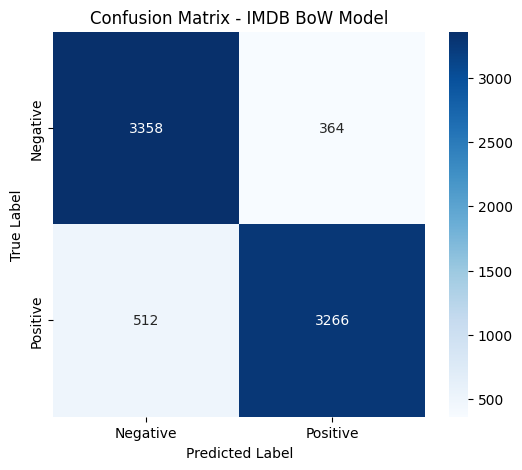

Confusion Matrix - IMDB LLaMa Model - Test Accuracy: 0.9524


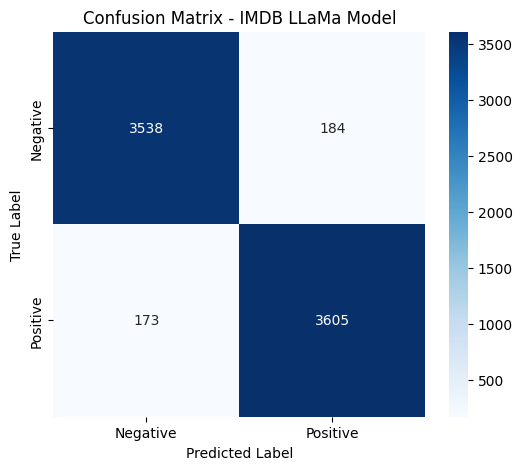

In [72]:
# Plot confusion matrices for final IMDB test set
plot_confusion_matrix(trained_model_bow_imdb, X_test_imdb_bow, y_test_imdb, title="Confusion Matrix - IMDB BoW Model")
plot_confusion_matrix(trained_model_llama_imdb, X_test_imdb_llama, y_test_imdb, title="Confusion Matrix - IMDB LLaMa Model")


In [73]:
!zip -r runs.zip runs

updating: runs/ (stored 0%)
updating: runs/bow/ (stored 0%)
updating: runs/bow/events.out.tfevents.1742039482.f19e2d48ada4.31.0 (deflated 95%)
updating: runs/bow_2/ (stored 0%)
updating: runs/bow_2/events.out.tfevents.1742039562.f19e2d48ada4.31.2 (deflated 95%)
updating: runs/llama/ (stored 0%)
updating: runs/llama/events.out.tfevents.1742039509.f19e2d48ada4.31.1 (deflated 95%)
updating: runs/llama_2/ (stored 0%)
updating: runs/llama_2/events.out.tfevents.1742039636.f19e2d48ada4.31.3 (deflated 95%)
  adding: runs/bow/events.out.tfevents.1742042175.f19e2d48ada4.31.4 (deflated 95%)
  adding: runs/bow_2/events.out.tfevents.1742042293.f19e2d48ada4.31.6 (deflated 95%)
  adding: runs/llama/events.out.tfevents.1742042198.f19e2d48ada4.31.5 (deflated 95%)
  adding: runs/llama_2/events.out.tfevents.1742042362.f19e2d48ada4.31.7 (deflated 95%)
